# Breast Cancer Integration and Gene Denoising

This additional example integrates three breast-cancer sections and demonstrates gene-expression denoising. The harmonized PCA representation is mapped back to the modeled genes and smoothed on the joint spatial graph.

In [1]:
from pathlib import Path
import sys
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import torch
from sklearn.metrics import adjusted_rand_score

cwd = Path.cwd().resolve()
PROJECT_ROOT = next(
    (path for path in (cwd, *cwd.parents) if (path / "SpaDiff").is_dir()),
    cwd,
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import SpaDiff as sd
from SpaDiff.spatial import spatial_reconstruction
from SpaDiff.utils import adjust_louvain_resolution, cal_purity, set_seed

## Configuration

In [ ]:
SEED = 42
SLICE_ORDER = ["H_1", "H_2", "H_3"]
REFERENCE_BATCH = "H_1"
TRUTH_KEY = "pathologist"
N_CLUSTERS = 7
K_INTRA = 5
K_INTER = 2
N_NEIGHBORS = 6
TOPOLOGY_MODE = "slice_aware"

MAX_ORDER = 2
SIMPLEX_ORDERS = (
    (0,) if MAX_ORDER == 0
    else tuple(range(1, MAX_ORDER + 1))
)
DSM_WEIGHTING = "variance"

PRIOR_KL_LOSS_WEIGHT = 0.0  

DATA_ROOT = Path("E:/gxy_2/final/0_data/case3/")
print("DATA_ROOT =", DATA_ROOT)

set_seed(SEED)
torch.backends.cudnn.deterministic = True
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("device =", device)

DATA_ROOT = E:\gxy_2\final\0_data\case3
device = cuda:0


## Data loading and preprocessing

In [25]:
samples = {}
for sample in SLICE_ORDER:
    current = sc.read_h5ad(DATA_ROOT / f"{sample}.h5ad")
    current.var_names_make_unique()
    current.layers["counts"] = current.X.copy()

    sc.pp.normalize_total(current, target_sum=1e4)
    sc.pp.log1p(current)
    current.layers["log1p"] = current.X.copy()
    current, _ = spatial_reconstruction(current, alpha=1.0, n_neighbors=N_NEIGHBORS)
    # sc.pp.scale(current, max_value=10)

    samples[sample] = current

adata = sc.concat(samples, join="inner", label="batch_name", index_unique="-")
adata.obs["batch_name"] = pd.Categorical(adata.obs["batch_name"], categories=SLICE_ORDER, ordered=True)
print(adata)
print(adata.obs["batch_name"].value_counts())
if TRUTH_KEY not in adata.obs:
    print(f"{TRUTH_KEY!r} was not found; purity and ARI evaluation will be skipped.")

AnnData object with n_obs × n_vars = 1726 × 13729
    obs: 'cluster', 'pathologist', 'batch_name'
    obsm: 'spatial'
    layers: 'counts', 'log1p'
batch_name
H_1    613
H_2    603
H_3    510
Name: count, dtype: int64


In [4]:
sc.pp.highly_variable_genes(adata, flavor="seurat_v3", layer="counts",n_top_genes=3000, batch_key="batch_name")
adata = adata[:, adata.var["highly_variable"]].copy()

sc.tl.pca(adata, n_comps=50)
pca_array = np.ascontiguousarray(adata.obsm["X_pca"], dtype=np.float32)
features = torch.from_numpy(pca_array).to(device)

## Spatial topology

In [5]:
topology = sd.build_spatial_topology(
    adata,
    mode=TOPOLOGY_MODE,
    batch_key="batch_name",
    slice_order=SLICE_ORDER,
    k_intra=K_INTRA,
    k_inter=K_INTER,
    max_order=MAX_ORDER,
    device=device,
)
operators = topology.operators

Simplicial complex statistics:
  order 0 (vertices): 1,726
  order 1 (edges): 6,444
  order 2 (triangles): 4,285


## SpaDiff training

In [6]:
config = sd.SpaDiffConfig(
    data_dim=features.shape[1],
    condition_input_dim=features.shape[1],
    score_depth=4,
    dropout=0.2,
    topology_projection_dropout=0.1,
    topology_residual=True,
    topology_output_normalization="feature",
    simplex_orders=SIMPLEX_ORDERS,
    propagation_steps=5,
    propagation_alpha=0.4,
    num_batches=len(SLICE_ORDER),
    dsm_weighting=DSM_WEIGHTING,
    prior_kl_weight=PRIOR_KL_LOSS_WEIGHT,
    batch_balanced_loss=True,
)
model = sd.SpaDiff(config).to(device)
adata = model.fit_transform(
    adata,
    features,
    operators,
    condition_features=features,
    batch_key="batch_name",
    batch_order=SLICE_ORDER,
    reference_batch=REFERENCE_BATCH,
    progress=True,
    ode_steps=250,
)

Training SpaDiff: 100%|██████████| 500/500 [00:10<00:00, 46.44epoch/s]


## Gene-expression denoising

We use this breast-cancer dataset as a compact denoising example.The output is stored in `adata.layers["spadiff_denoised"]`.

In [8]:
adata = sd.write_denoised_expression(
    adata,
    latent_key="X_spadiff",
    loadings_key="PCs",
    layer_key="spadiff_denoised",
    adjacency=topology.adjacency,
    smoothing_alpha=1.0,
    clip_nonnegative=True,
)
print("denoised layer:", adata.layers["spadiff_denoised"].shape)

denoised layer: (1726, 3000)


## Spatial domains

In [17]:
sc.pp.neighbors(adata, use_rep='X_spadiff', n_neighbors=15, random_state=SEED)
sc.tl.louvain( adata, key_added="louvain", resolution=0.91, random_state=SEED)

In [39]:
if TRUTH_KEY in adata.obs:
    for sample in SLICE_ORDER:
        subset_obs = adata.obs.loc[adata.obs["batch_name"] == sample]
        valid = subset_obs[[TRUTH_KEY, "louvain"]].dropna()
        truth_codes = pd.Categorical(valid[TRUTH_KEY]).codes
        pred_codes = pd.Categorical(valid["louvain"]).codes
        purity = cal_purity(truth_codes, pred_codes)
        # ari = adjusted_rand_score(truth_codes, pred_codes)
        print(f"{sample}: purity={purity:.3f}")

    valid = adata.obs[[TRUTH_KEY, "louvain"]].dropna()
    truth_codes = pd.Categorical(valid[TRUTH_KEY]).codes
    pred_codes = pd.Categorical(valid["louvain"]).codes
    purity = cal_purity(truth_codes, pred_codes)
    # ari = adjusted_rand_score(truth_codes, pred_codes)
    print(f"all sections: purity={purity:.3f}")

H_1: purity=0.861
H_2: purity=0.799
H_3: purity=0.782
all sections: purity=0.816


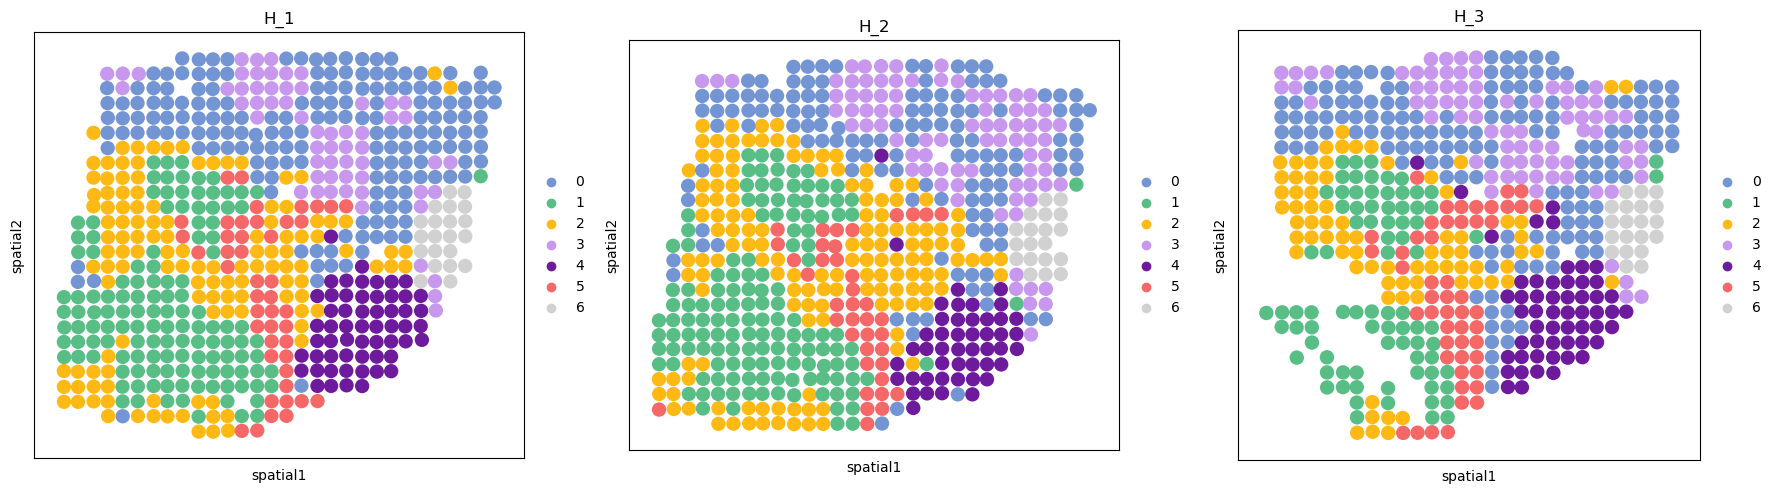

In [32]:
plot_color = ["#7495D3", "#59BE86", "#FEB915", "#C798EE", "#6D1A9C", "#F56867", "#D1D1D1"]
fig, axes = plt.subplots(1, len(SLICE_ORDER), figsize=(18, 5))
for axis, sample in zip(np.atleast_1d(axes), SLICE_ORDER):
    subset = adata[adata.obs["batch_name"] == sample].copy()
    sc.pl.spatial(
        subset, color="louvain", ax=axis, show=False, spot_size=280,
        palette=plot_color, title=sample,
        # legend_loc=None,
    )
plt.tight_layout()
plt.show()

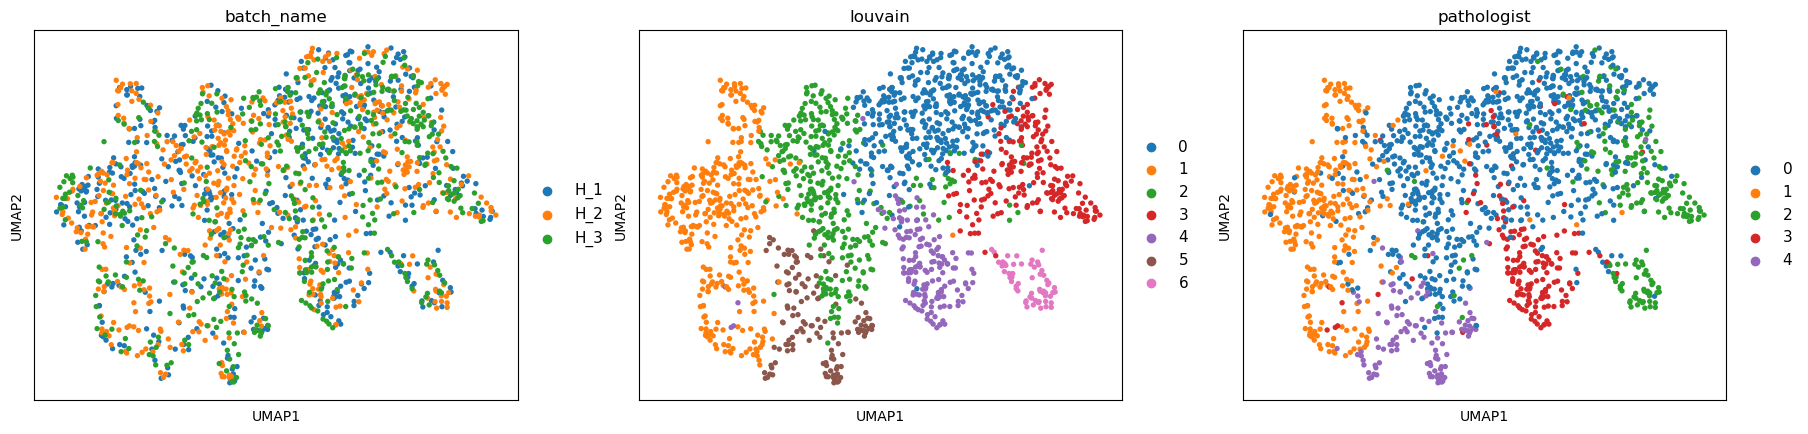

In [36]:
sc.tl.umap(adata, random_state=SEED)
colors = ["batch_name", "louvain"]
if TRUTH_KEY in adata.obs:
    colors.append(TRUTH_KEY)
sc.pl.umap(
    adata, color=colors, size=60,
    legend_fontsize=11, legend_fontoutline=2,
)

## Inspect a denoised gene

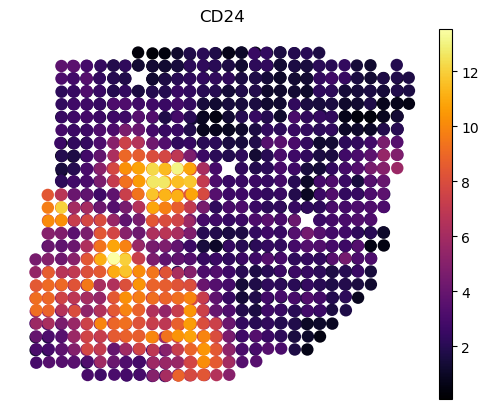

In [21]:
genes = "CD24"
sc.pl.spatial(
    adata,
    color=genes,
    layer='spadiff_denoised',
    spot_size=280,                      
    color_map='inferno',                 
    legend_loc=None,
    frameon=False, 
)

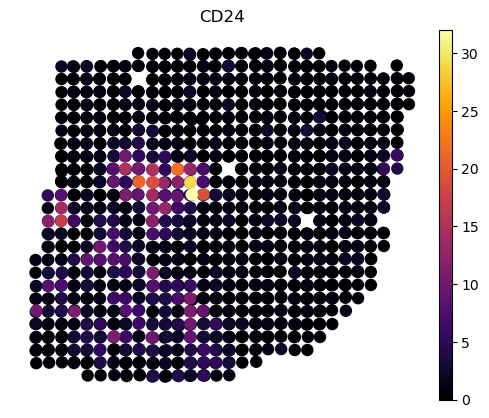

In [28]:
genes = "CD24"
sc.pl.spatial(
    adata,
    color=genes,
    layer='counts',
    spot_size=280,                      
    color_map='inferno',                 
    legend_loc=None,
    frameon=False, 
)